In [75]:
import numpy as np
import pandas as pd
import json
import datetime
import matplotlib.pyplot as plt
from IPython.core.display import HTML

In [3]:
with open('data.json','r') as file:
    data = json.load(file)

In [4]:
len(data)

468

In [5]:
visited = set()
encoded = []
for i, record in enumerate(data):
    key = f"{record['WORKER_ID']}/{record['WORK']['taskId']}"
    if key in visited or len(key)!=41: continue
    visited.add(key)
    work=record['WORK']
    for j, row in enumerate(work['items']):
        encoded.append({
            "worker_id": work['workerId'],
            "start_time": datetime.datetime.fromtimestamp(round(row['startTime']/1000)),
            "end_time": datetime.datetime.fromtimestamp(round(row['endTime']/1000)),
            "group": work['group'],
            "paramoji1": [int(x) for x in row['face1']['paramoji']],
            "paramoji2": [int(x) for x in row['face2']['paramoji']],
            "value1": row['value1'],
            "value2": row['value2'],
        })
encoded= pd.DataFrame(encoded)

In [6]:
encoded

,worker_id,start_time,end_time,group,paramoji1,paramoji2,value1,value2
0,23529476,2023-07-20 10:27:34,2023-07-20 10:27:55,B,"[69, 90, 20, 96, 100]","[33, 59, 69, 47, 98]",-1,1
1,23529476,2023-07-20 10:27:55,2023-07-20 10:28:03,B,"[61, 37, 27, 22, 59]","[18, 43, 33, 0, 88]",-1,1
2,23529476,2023-07-20 10:28:03,2023-07-20 10:28:07,B,"[43, 33, 86, 69, 84]","[71, 92, 18, 12, 71]",1,-1
3,23529476,2023-07-20 10:28:07,2023-07-20 10:28:15,B,"[12, 4, 22, 59, 55]","[35, 57, 82, 84, 63]",-1,1
4,23529476,2023-07-20 10:28:15,2023-07-20 10:28:17,B,"[53, 39, 65, 43, 51]","[37, 18, 92, 14, 86]",-1,1
...,...,...,...,...,...,...,...,...
13185,d07433fa,2023-08-01 17:45:00,2023-08-01 17:45:03,A,"[61, 84, 35, 49, 0]","[45, 94, 59, 86, 61]",1,-1
13186,d07433fa,2023-08-01 17:45:03,2023-08-01 17:45:06,A,"[10, 16, 47, 35, 2]","[82, 65, 29, 88, 71]",-1,1
13187,d07433fa,2023-08-01 17:45:06,2023-08-01 17:45:11,A,"[67, 8, 94, 84, 18]","[51, 92, 39, 33, 29]",0,0
13188,d07433fa,2023-08-01 17:45:11,2023-08-01 17:45:16,A,"[2, 63, 63, 76, 35]","[22, 82, 71, 0, 53]",1,-1


In [7]:
print(f"{len(set(encoded['worker_id']))} workers")

420 workers


In [8]:
print(f"{encoded.shape[0]} submissions")

13190 submissions


In [9]:
secs = (encoded['end_time'] - encoded['start_time']).map(lambda x:x.seconds)
print(f"Average time spent {np.mean(secs):.2f}")

Average time spent 9.96


In [10]:
M = np.eye(5)
M[1:3,1:3]=np.array([[1,1],[1,-1]])/np.sqrt(2)
M = M[[0,1,3,2,4]].T
M

array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678,  0.        ,  0.70710678,  0.        ],
       [ 0.        ,  0.70710678,  0.        , -0.70710678,  0.        ],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ]])

In [11]:
def extract_group(g):
    input = np.concatenate((
        np.array(encoded.query("group==@g")['paramoji1'].to_list()) @ M,
        np.array(encoded.query("group==@g")['paramoji2'].to_list()) @ M
    ))/100
    output = np.concatenate((
        np.array(encoded.query("group==@g")['value1'].to_list()),
        np.array(encoded.query("group==@g")['value2'].to_list())
    ))/2 + .5
    return input, output

In [12]:
group_map={
    "A": "Valence",
    "B": "Arousal",
    "C": "Dominance",
    "D": "Control",
    "E": "Contempt"
}

In [13]:
def add_norm(df):
    df['sum'] = np.sum(np.abs(df.iloc[:,0:5].to_numpy()), axis=1)
    return df

In [14]:
coeffs = []
groups = ['A','C','D','B','E']
for g in groups:
    input, output = extract_group(g)
    input= np.vstack((input.T, np.ones(output.shape))).T
    mc = np.linalg.lstsq(input, output, rcond=None)[0]
    coeffs.append(mc[:5])
coeffs = np.array(coeffs)
coeffs = pd.DataFrame(coeffs, index=[group_map[g] for g in groups])
add_norm(coeffs)
coeffs

,0,1,2,3,4,sum
Valence,0.536028,0.008523,-0.210508,0.092148,-0.158128,1.005336
Dominance,-0.054880,0.002877,0.194083,0.015535,0.014902,0.282277
Control,0.283522,-0.042528,-0.103339,0.184001,-0.104486,0.717875
Arousal,-0.285290,0.087820,0.162757,-0.076283,0.058239,0.670390
Contempt,-0.238048,0.037335,0.202578,-0.005114,0.081621,0.564697


In [15]:
def proj(u,v):
    return u.T @ v / (u.T @ u) * u

In [16]:
ortho = coeffs.copy().iloc[:,:5]
for i in range(ortho.shape[0]):
    for j in range(i+1,ortho.shape[0]):
        ortho.iloc[j,:5] = ortho.iloc[j,:5] - proj(ortho.iloc[i,:5], ortho.iloc[j,:5])
add_norm(ortho)
ortho

,0,1,2,3,4,sum
Valence,0.536028,0.008523,-0.210508,0.092148,-0.158128,1.005336
Dominance,0.049584,0.004538,0.153058,0.033493,-0.015915,0.256589
Control,-0.030746,-0.048332,-0.017068,0.124599,-0.011499,0.232245
Arousal,-0.015251,0.070096,-0.004645,0.020016,-0.030072,0.140079
Contempt,0.005705,0.010067,-0.001117,0.007537,0.025760,0.050186


<Axes: >

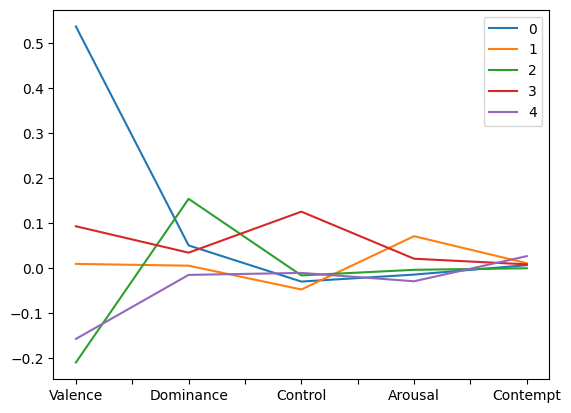

In [17]:
ortho.iloc[:,:5].plot()

In [18]:
print(coeffs.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrr}
\toprule
{} &     0 &     1 &     2 &     3 &     4 &  sum \\
\midrule
Valence   &  0.54 &  0.01 & -0.21 &  0.09 & -0.16 & 1.01 \\
Dominance & -0.05 &  0.00 &  0.19 &  0.02 &  0.01 & 0.28 \\
Control   &  0.28 & -0.04 & -0.10 &  0.18 & -0.10 & 0.72 \\
Arousal   & -0.29 &  0.09 &  0.16 & -0.08 &  0.06 & 0.67 \\
Contempt  & -0.24 &  0.04 &  0.20 & -0.01 &  0.08 & 0.56 \\
\bottomrule
\end{tabular}



/var/folders/js/6y0d6ks969bcc5gvn82hk7xc0000gn/T/ipykernel_3062/2812489912.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(coeffs.to_latex(float_format="%.2f"))


In [142]:
print(ortho.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrr}
\toprule
{} &     0 &     1 &     2 &    3 &     4 &  sum \\
\midrule
Valence   &  0.54 &  0.01 & -0.21 & 0.09 & -0.16 & 1.01 \\
Dominance &  0.05 &  0.00 &  0.15 & 0.03 & -0.02 & 0.26 \\
Control   & -0.03 & -0.05 & -0.02 & 0.12 & -0.01 & 0.23 \\
Arousal   & -0.02 &  0.07 & -0.00 & 0.02 & -0.03 & 0.14 \\
Contempt  &  0.01 &  0.01 & -0.00 & 0.01 &  0.03 & 0.05 \\
\bottomrule
\end{tabular}



/var/folders/js/6y0d6ks969bcc5gvn82hk7xc0000gn/T/ipykernel_3062/1829069667.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(ortho.to_latex(float_format="%.2f"))


In [341]:
ortho.to_csv('results.csv')

In [156]:
c2e = ortho.iloc[:, :5] @ np.linalg.inv(M)
c2e

,0,1,2,3,4
Valence,0.536028,0.071185,-0.059132,-0.210508,-0.158128
Dominance,0.049584,0.026892,-0.020474,0.153058,-0.015915
Control,-0.030746,0.053928,-0.122281,-0.017068,-0.011499
Arousal,-0.015251,0.063719,0.035412,-0.004645,-0.030072
Contempt,0.005705,0.012448,0.001789,-0.001117,0.025760


In [157]:
e2c = np.linalg.inv(c2e)
e2c = e2c / np.max(np.abs(e2c), axis=0, keepdims=True)
e2c

array([[ 1.        ,  0.32395385, -0.25144074, -0.23934655,  0.22145659],
       [ 0.13280173,  0.17570076,  0.44102119,  1.        ,  0.483207  ],
       [-0.11031464, -0.13376908, -1.        ,  0.55575998,  0.06943457],
       [-0.39271866,  1.        , -0.13958016, -0.07289464, -0.04337126],
       [-0.29500037, -0.10398209, -0.09404051, -0.47195262,  1.        ]])

In [158]:
p0 = [.5, .5, .5, .5, .25]
b = p0 - e2c @ p0
b

array([ 0.02805257, -0.49556359,  0.82680323,  0.31343955,  0.48248779])

In [159]:
e2c @ p0 + b

array([0.5 , 0.5 , 0.5 , 0.5 , 0.25])

In [160]:
html = ""
for i in range(5):
    for d in [0, 1/3, 2/3, 1]:
        p= p0.copy()
        p[i] = d
        x = np.round(100 * (e2c @ p + b))
        html += f'<img src="https://paramoji.org/paramoji.svg.php?v={x[0]}&a1={x[1]}&a2={x[2]}&d={x[3]}&c={x[4]}&size=100"/>'
    html += "<br/>"
HTML("<div>"+ html+"</html>")

In [165]:
for i in range(5):
    print("\\begin{figure}[ht!]")
    print("  \\begin{center}")
    print("    \\begin{tabular}{cccc}")
    for d in [0, 1/3, 2/3, 1]:
        p= p0.copy()
        p[i] = d
        x = np.array(np.round(100 * (e2c @ p + b)), dtype='int') 
        print(f"        \paramoji{{{x[0]},{x[1]},{x[2]},{x[3]},{x[4]}}}")
    print("    \\end{tabular}")
    print("  \\end{center}")
    print("  \\label{fig:emp_" + ortho.index[i].lower() + "}")
    print("  \\caption{" + ortho.index[i] + "}")
    print("\\end{figure}")
    print()


\begin{figure}[ht!]
  \begin{center}
    \begin{tabular}{cccc}
        \paramoji{0,43,56,70,40}
        \paramoji{33,48,52,57,30}
        \paramoji{67,52,48,43,20}
        \paramoji{100,57,44,30,10}
    \end{tabular}
  \end{center}
  \label{fig:emp_valence}
  \caption{Valence}
\end{figure}

\begin{figure}[ht!]
  \begin{center}
    \begin{tabular}{cccc}
        \paramoji{34,41,57,0,30}
        \paramoji{45,47,52,33,27}
        \paramoji{55,53,48,67,23}
        \paramoji{66,59,43,100,20}
    \end{tabular}
  \end{center}
  \label{fig:emp_dominance}
  \caption{Dominance}
\end{figure}

\begin{figure}[ht!]
  \begin{center}
    \begin{tabular}{cccc}
        \paramoji{63,28,100,57,30}
        \paramoji{54,43,67,52,27}
        \paramoji{46,57,33,48,23}
        \paramoji{37,72,0,43,20}
    \end{tabular}
  \end{center}
  \label{fig:emp_control}
  \caption{Control}
\end{figure}

\begin{figure}[ht!]
  \begin{center}
    \begin{tabular}{cccc}
        \paramoji{62,0,22,54,49}
        \paramoji{54,33,

In [164]:
print("\\left(")
print("\\begin{array}{c}")
print("  " + " \\\\ ".join(["v", "a_1", "a_2", "d", "c"]))
print("\\end{array}\n\\right) =")
print("\\left(")
print("\\begin{array}{ccccc}")
for i in range(5):
    for j in range(5):
        if j>0: 
            print(" & ", end="")
        else:
            print("  ", end="")
        print(f"{e2c[j,i]:+2.2f}", end="")
    print(" \\\\")
print("\\end{array}\n\\right) \\left(")
print("\\begin{array}{c}")
print("  " + " \\\\ ".join([x+"^e" for x in ["v", "d", "o", "a", "c"]]))
print("\\end{array}\n\\right) + \\left(")
print("\\begin{array}{c}")
print("  " + " \\\\ ".join([f"{x:+2.2f}" for x in b.tolist()]))
print("\\end{array}\n\\right)")


\left(
\begin{array}{c}
  v \\ a_1 \\ a_2 \\ d \\ c
\end{array}
\right) =
\left(
\begin{array}{ccccc}
  +1.00 & +0.13 & -0.11 & -0.39 & -0.30 \\
  +0.32 & +0.18 & -0.13 & +1.00 & -0.10 \\
  -0.25 & +0.44 & -1.00 & -0.14 & -0.09 \\
  -0.24 & +1.00 & +0.56 & -0.07 & -0.47 \\
  +0.22 & +0.48 & +0.07 & -0.04 & +1.00 \\
\end{array}
\right) \left(
\begin{array}{c}
  v^e \\ d^e \\ d^e \\ o^e \\ a^e \\ c^e
\end{array}
\right) + \left(
\begin{array}{c}
  +0.03 \\ -0.50 \\ +0.83 \\ +0.31 \\ +0.48
\end{array}
\right)
